In [ ]:
!pip install -q \
    "pandas==2.2.3" \
    "scanpy==1.11.5" \
    "anndata==0.12.19" \
    "gseapy==1.3.1"

In [ ]:
import scanpy as sc
import anndata as ad
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Pandas:", pd.__version__)
print("Scanpy:", sc.__version__)
print("AnnData:", ad.__version__)

Pandas: 2.2.3
Scanpy: 1.11.5
AnnData: 0.12.19


/tmp/ipykernel_23280/3614177062.py:8: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  print("Scanpy:", sc.__version__)
/tmp/ipykernel_23280/3614177062.py:9: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  print("AnnData:", ad.__version__)


In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from pathlib import Path

file_path = Path(
    "/content/drive/MyDrive/sc-project3-IFN-I/merged_qc_filtered.h5ad"
)

print(file_path.exists())

True


In [ ]:
adata = sc.read_h5ad(file_path)

print(adata)
print(f"Cells: {adata.n_obs:,}")
print(f"Genes: {adata.n_vars:,}")

AnnData object with n_obs × n_vars = 94513 × 31054
    obs: 'sample', 'donor_type', 'sample_batch', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'pct_counts_hb', 'n_genes'
    var: 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells'
Cells: 94,513
Genes: 31,054


In [ ]:
adata.layers["counts"] = adata.X.copy()

In [ ]:
# Total count normalization to 10,000 and log-transform
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
adata.raw = adata

In [ ]:
sc.pp.highly_variable_genes(
    adata,
    n_top_genes=2500,
    batch_key="sample"
)

In [ ]:
print(
    "Highly variable genes:",
    adata.var["highly_variable"].sum()
)

Highly variable genes: 2500


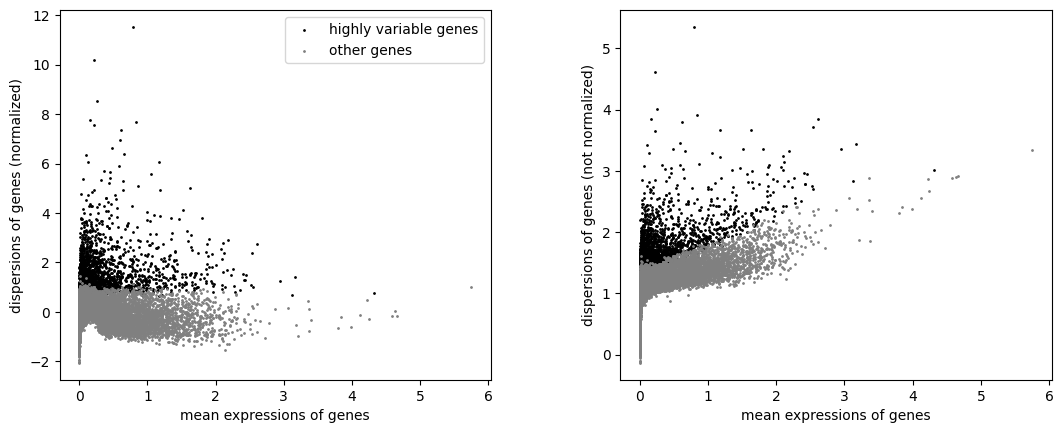

In [ ]:
sc.pl.highly_variable_genes(adata)

In [ ]:
adata.write_h5ad(
    "/content/normalized_hvg.h5ad"
)

In [ ]:
!ls -lh /content/normalized_hvg.h5ad

-rw-r--r-- 1 root root 4.5G Aug 29 08:39 /content/normalized_hvg.h5ad


In [ ]:
adata.write_h5ad(
    "/content/drive/MyDrive/sc-project3-IFN-I/normalized_hvg.h5ad"
)

In [ ]:
adata = sc.read_h5ad(
    "/content/drive/MyDrive/sc-project3-IFN-I/normalized_hvg.h5ad"
)

print(adata)

AnnData object with n_obs × n_vars = 94513 × 31054
    obs: 'sample', 'donor_type', 'sample_batch', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'pct_counts_hb', 'n_genes'
    var: 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'hvg', 'log1p'
    layers: 'counts'


In [ ]:
print("Cells:", adata.n_obs)
print("Genes:", adata.n_vars)
print("HVGs:", adata.var["highly_variable"].sum())

Cells: 94513
Genes: 31054
HVGs: 2500


In [ ]:
adata = adata[:, adata.var["highly_variable"]].copy()

print("After HVG subsetting:")
print("Cells:", adata.n_obs)
print("Genes:", adata.n_vars)

After HVG subsetting:
Cells: 94513
Genes: 2500


In [ ]:
adata.write_h5ad(
    "/content/drive/MyDrive/sc-project3-IFN-I/hvg_subset.h5ad"
)

In [ ]:
adata = sc.read_h5ad(
    "/content/drive/MyDrive/sc-project3-IFN-I/hvg_subset.h5ad"
)

print(adata)

AnnData object with n_obs × n_vars = 94513 × 2500
    obs: 'sample', 'donor_type', 'sample_batch', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'pct_counts_hb', 'n_genes'
    var: 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'hvg', 'log1p'
    layers: 'counts'


In [ ]:
sc.pp.regress_out(
    adata,
    ["total_counts", "pct_counts_mt"]
)

/usr/local/lib/python3.13/dist-packages/scanpy/preprocessing/_simple.py:666: NumbaPerformanceWarning: '@' is faster on contiguous arrays, called on (Array(float64, 1, 'A', False, aligned=True), Array(float64, 2, 'C', False, aligned=True))
  data[i] -= regressor[i] @ coeff
/usr/local/lib/python3.13/dist-packages/scanpy/preprocessing/_simple.py:666: NumbaPerformanceWarning: '@' is faster on contiguous arrays, called on (Array(float64, 1, 'A', False, aligned=True), Array(float64, 2, 'C', False, aligned=True))
  data[i] -= regressor[i] @ coeff


In [ ]:
sc.pp.scale(
    adata,
    max_value=10
)

In [ ]:
adata.write_h5ad(
    "/content/drive/MyDrive/sc-project3-IFN-I/normalized_hvg_regressed_scaled.h5ad"
)

Although the original workflow specifies identifying 2,500 highly variable genes before regression, the `highly_variable_genes()` function in Scanpy only annotates the selected genes and does not automatically remove the remaining genes from the expression matrix. Therefore, regression would otherwise be performed on all 31,054 genes rather than the 2,500 HVGs selected for downstream analysis. Given the large dataset size (94,513 cells × 31,054 genes) and the substantial memory requirements of `sc.pp.regress_out()`, the dataset was explicitly subsetted to the 2,500 HVGs before regression. This modification preserves the intended downstream analysis—using the selected informative genes for dimensionality reduction—while substantially reducing computational and memory requirements. The full normalized and log-transformed expression matrix was retained in `adata.raw`, ensuring that information from the non-HVGs was not permanently lost.


| File                                   | What it represents                                                                           |
| -------------------------------------- | -------------------------------------------------------------------------------------------- |
| `merged_qc_filtered.h5ad`              | QC-filtered data, before normalization                                                       |
| `normalized_hvg.h5ad`                  | Normalized + log-transformed data; 2,500 HVGs identified, but **31,054 genes still present** |
| `hvg_subset.h5ad`                      | 2,500 HVGs only, if you successfully saved this                                              |
| `normalized_hvg_regressed_scaled.h5ad` | **End of 8.3**: 2,500 HVGs + regression + scaling, if you successfully saved it              |
| `pca.h5ad`                             | **End of 8.4**: previous processing + PCA                                                    |
